In [ ]:
# =========================================
# SECTION 1: IMPORT LIBRARIES
# =========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC

!pip install xgboost
from xgboost import XGBClassifier

In [ ]:
# =========================================
# SECTION 2: LOAD DATASET
# =========================================
uploaded = files.upload()

df = pd.read_csv('UCI_Credit_Card.csv')

df.drop(['ID'], axis=1, inplace=True)
df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)

df.head()

Saving UCI_Credit_Card.csv to UCI_Credit_Card.csv


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


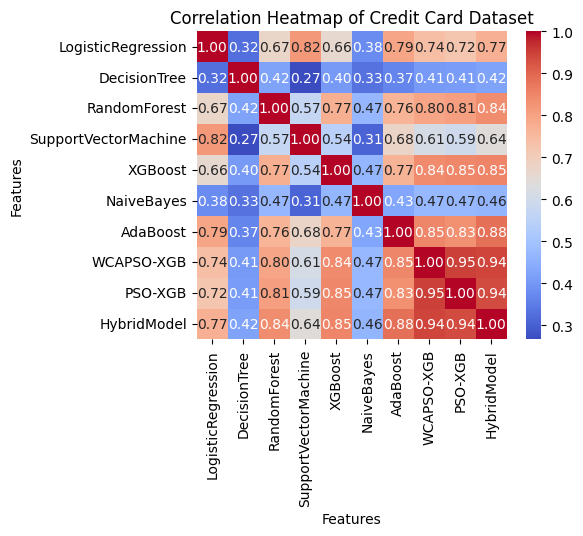

In [ ]:
# =========================================
# SECTION: CORRELATION HEATMAP
# Purpose: Analyze relationships between variables
# =========================================


plt.figure(figsize=(5,4))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    annot=True,      # 👈 shows values
    fmt=".2f"        # 👈 limits decimals
)

plt.title("Correlation Heatmap of Credit Card Dataset")
plt.xlabel("Features")
plt.ylabel("Features")

plt.show()

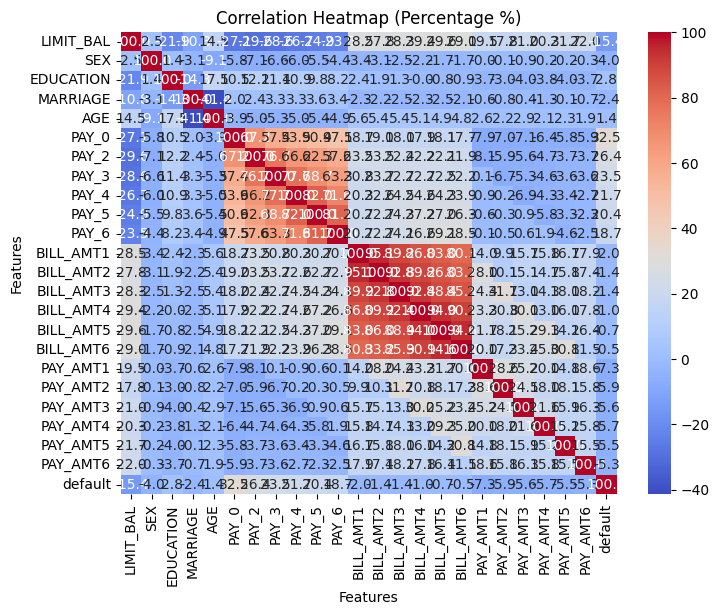

In [ ]:
# Correlation matrix
corr = df.corr()

# Convert to percentage
corr_percent = corr * 100

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_percent,
    annot=True,
    fmt=".1f",        # 1 decimal place
    cmap='coolwarm'
)

plt.title("Correlation Heatmap (Percentage %)")
plt.xlabel("Features")
plt.ylabel("Features")

plt.show()

In [ ]:
# =========================================
# SECTION 4: DEFINE FEATURES & TARGET
# =========================================
X = df.drop('default', axis=1)
y = df['default']

In [ ]:
# =========================================
# SECTION 5: TRAIN-TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [ ]:
# =========================================
# SECTION 6: FEATURE SCALING
# =========================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

***** Logistic Regression *****
Training Accuracy: 0.810875


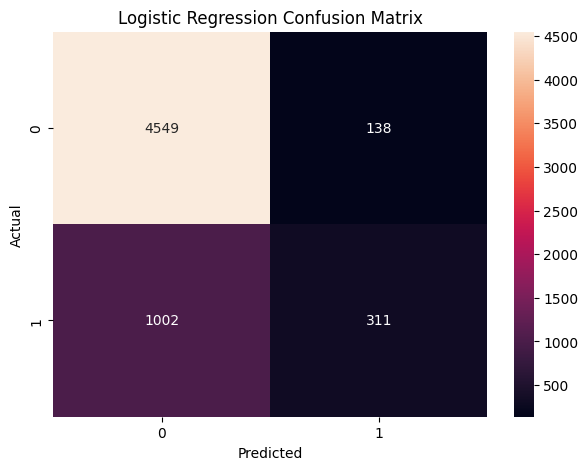

Testing Accuracy =  0.81
***** Logistic Regression Classification Report *****
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.69      0.24      0.35      1313

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



In [ ]:
# =========================================
# SECTION: LOGISTIC REGRESSION
# Purpose: Build baseline classification model
# =========================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Train Model
log = LogisticRegression(max_iter=1000)
log.fit(X_train, y_train)

print('***** Logistic Regression *****')
print('Training Accuracy:', log.score(X_train, y_train))

# Prediction
y_pred_lr = log.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Accuracy Calculation
TP, FP, FN, TN = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
lrTest = (TP + TN) / (TP + TN + FP + FN)

print('Testing Accuracy = ', lrTest)

# Classification Report
print('***** Logistic Regression Classification Report *****')
print(classification_report(y_test, y_pred_lr))

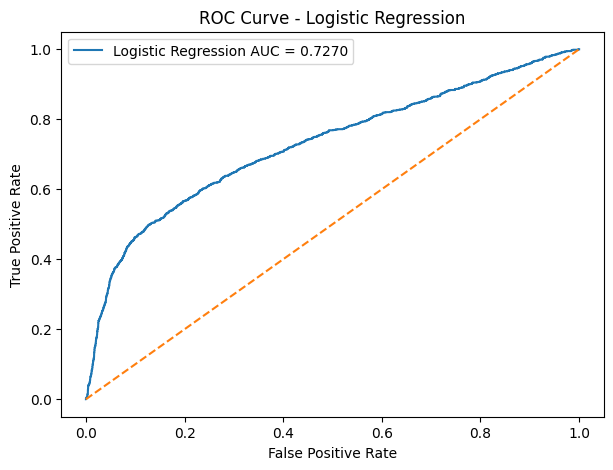

AUC Score: 0.7269867506354779


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ---------------------------
# Probabilities from Logistic Regression
# ---------------------------
lr_proba = log.predict_proba(X_test)[:, 1]

# ---------------------------
# ROC Curve
# ---------------------------
fpr, tpr, _ = roc_curve(y_test, lr_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Logistic Regression AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

Training Accuracy: 0.8022916666666666


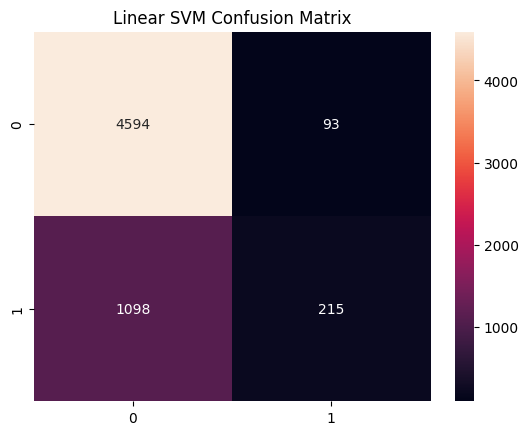

              precision    recall  f1-score   support

           0       0.81      0.98      0.89      4687
           1       0.70      0.16      0.27      1313

    accuracy                           0.80      6000
   macro avg       0.75      0.57      0.58      6000
weighted avg       0.78      0.80      0.75      6000



In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Train Linear SVM (FAST + BEST for large dataset)
svc = LinearSVC(C=1.0, max_iter=5000)
svc.fit(X_train, y_train)

print("Training Accuracy:", svc.score(X_train, y_train))

# Prediction
y_pred_svc = svc.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svc)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Linear SVM Confusion Matrix")
plt.show()

# Report
print(classification_report(y_test, y_pred_svc))

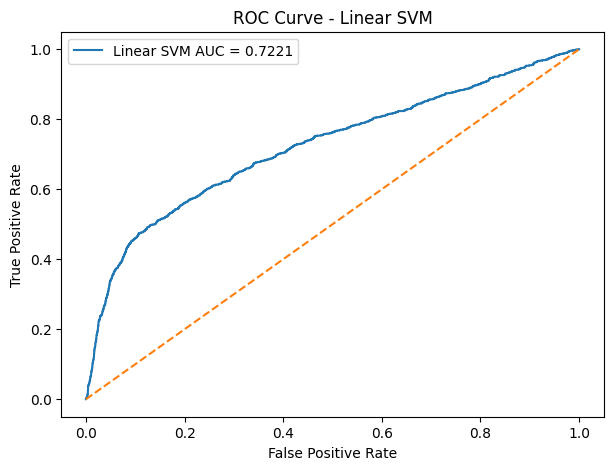

AUC Score: 0.722059736130676


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ---------------------------
# Decision scores (NOT probability)
# ---------------------------
svc_score = svc.decision_function(X_test)

# ---------------------------
# ROC Curve
# ---------------------------
fpr, tpr, _ = roc_curve(y_test, svc_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Linear SVM AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Linear SVM")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

***** Random Forest *****
Training Accuracy: 0.999375


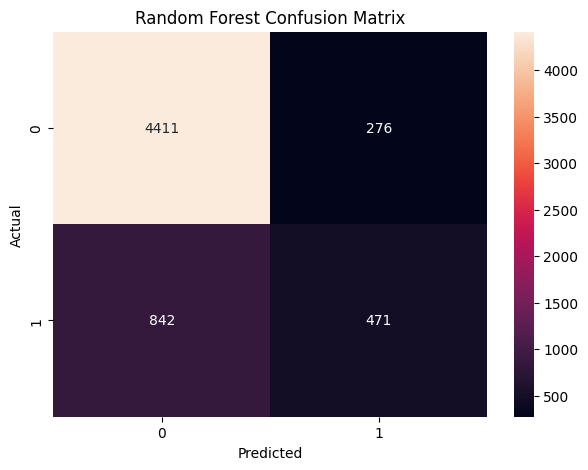

Testing Accuracy =  0.8136666666666666
***** Random Forest Classification Report *****
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4687
           1       0.63      0.36      0.46      1313

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000



In [ ]:
# =========================================
# MODEL 2: RANDOM FOREST
# =========================================
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=0)
forest.fit(X_train, y_train)

print('***** Random Forest *****')
print('Training Accuracy:', forest.score(X_train, y_train))

# Prediction
y_pred_rf = forest.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Accuracy
TP, FP, FN, TN = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
rfTest = (TP + TN) / (TP + TN + FP + FN)

print('Testing Accuracy = ', rfTest)

# Classification Report
print('***** Random Forest Classification Report *****')
print(classification_report(y_test, y_pred_rf))

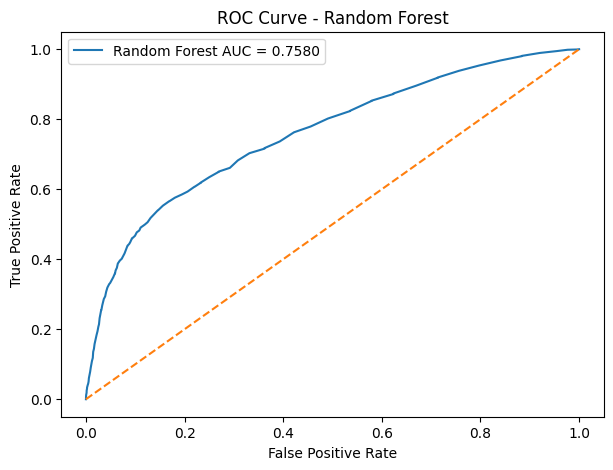

AUC Score: 0.7580057689017167


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ---------------------------
# Probabilities from Random Forest
# ---------------------------
rf_proba = forest.predict_proba(X_test)[:, 1]

# ---------------------------
# ROC Curve
# ---------------------------
fpr, tpr, _ = roc_curve(y_test, rf_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Random Forest AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

***** XGBoost *****
Training Accuracy: 0.885375


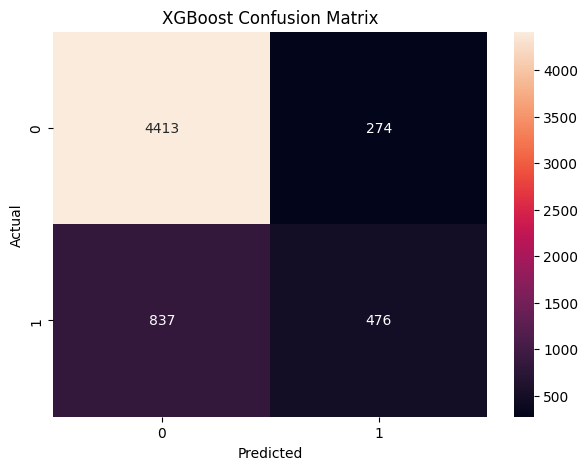

Testing Accuracy =  0.8148333333333333
***** XGBoost Classification Report *****
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4687
           1       0.63      0.36      0.46      1313

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.80      0.81      0.79      6000



In [ ]:
# =========================================
# MODEL 3: XGBOOST
# =========================================
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)

print('***** XGBoost *****')
print('Training Accuracy:', xgb.score(X_train, y_train))

# Prediction
y_pred_xgb = xgb.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Accuracy
TP, FP, FN, TN = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
xgbTest = (TP + TN) / (TP + TN + FP + FN)

print('Testing Accuracy = ', xgbTest)

# Classification Report
print('***** XGBoost Classification Report *****')
print(classification_report(y_test, y_pred_xgb))

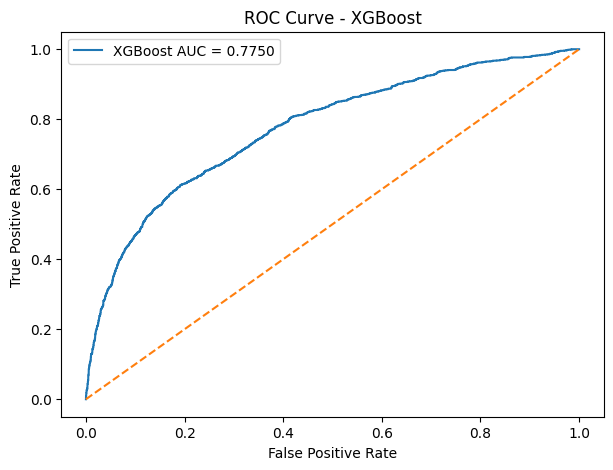

AUC Score: 0.7749595346529778


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ---------------------------
# Probabilities from XGBoost
# ---------------------------
xgb_proba = xgb.predict_proba(X_test)[:, 1]

# ---------------------------
# ROC Curve
# ---------------------------
fpr, tpr, _ = roc_curve(y_test, xgb_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'XGBoost AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

***** Decision Tree *****
Training Accuracy: 0.9994583333333333


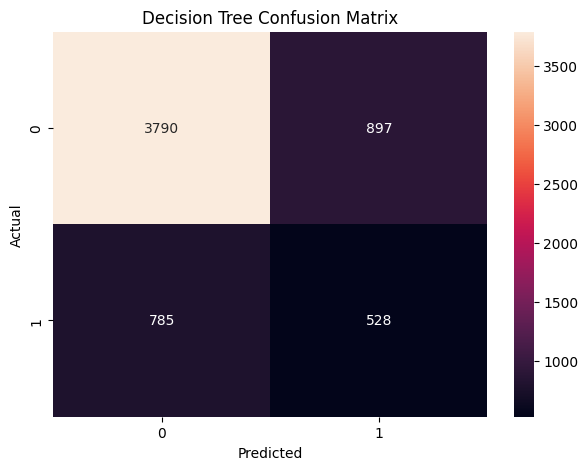

Testing Accuracy =  0.7196666666666667
***** Decision Tree Classification Report *****
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      4687
           1       0.37      0.40      0.39      1313

    accuracy                           0.72      6000
   macro avg       0.60      0.61      0.60      6000
weighted avg       0.73      0.72      0.72      6000



In [ ]:
# =========================================
# MODEL 4: DECISION TREE
# =========================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report

tree = DecisionTreeClassifier(criterion='entropy', random_state=0)
tree.fit(X_train, y_train)

print('***** Decision Tree *****')
print('Training Accuracy:', tree.score(X_train, y_train))

# Prediction
y_pred_dt = tree.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Accuracy Calculation
TP, FP, FN, TN = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
dtTest = (TP + TN) / (TP + TN + FP + FN)

print('Testing Accuracy = ', dtTest)

# Classification Report
print('***** Decision Tree Classification Report *****')
print(classification_report(y_test, y_pred_dt))

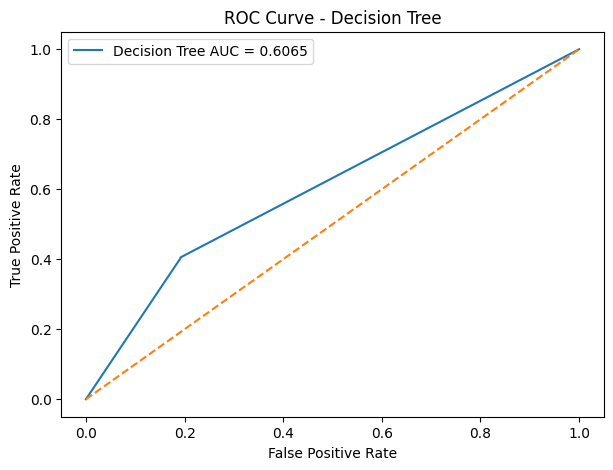

AUC Score: 0.6064800453556376


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ---------------------------
# Probabilities from Decision Tree
# ---------------------------
dt_proba = tree.predict_proba(X_test)[:, 1]

# ---------------------------
# ROC Curve
# ---------------------------
fpr, tpr, _ = roc_curve(y_test, dt_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Decision Tree AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

***** Naive Bayes *****
Training Accuracy: 0.7137916666666667


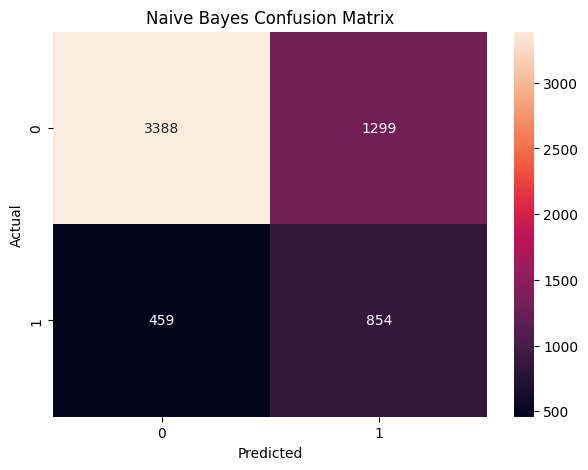

Testing Accuracy =  0.707
***** Naive Bayes Classification Report *****
              precision    recall  f1-score   support

           0       0.88      0.72      0.79      4687
           1       0.40      0.65      0.49      1313

    accuracy                           0.71      6000
   macro avg       0.64      0.69      0.64      6000
weighted avg       0.77      0.71      0.73      6000



In [ ]:
# =========================================
# MODEL 5: NAIVE BAYES
# =========================================
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report

nb = GaussianNB()
nb.fit(X_train, y_train)

print('***** Naive Bayes *****')
print('Training Accuracy:', nb.score(X_train, y_train))

# Prediction
y_pred_nb = nb.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Accuracy Calculation
TP, FP, FN, TN = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
nbTest = (TP + TN) / (TP + TN + FP + FN)

print('Testing Accuracy = ', nbTest)

# Classification Report
print('***** Naive Bayes Classification Report *****')
print(classification_report(y_test, y_pred_nb))

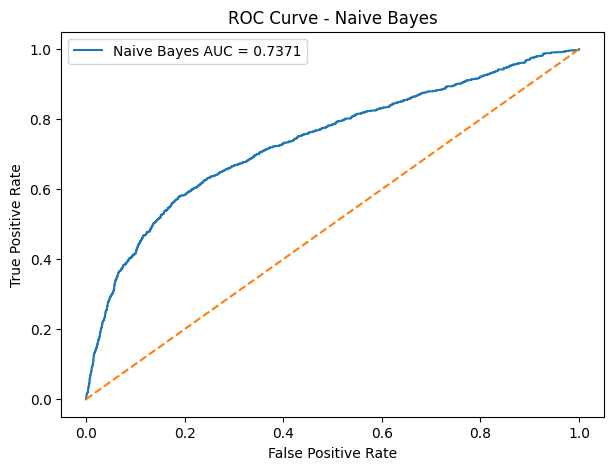

AUC Score: 0.7370833848578273


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ---------------------------
# Probabilities from Naive Bayes
# ---------------------------
nb_proba = nb.predict_proba(X_test)[:, 1]

# ---------------------------
# ROC Curve
# ---------------------------
fpr, tpr, _ = roc_curve(y_test, nb_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Naive Bayes AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

***** AdaBoost *****
Training Accuracy: 0.8192083333333333


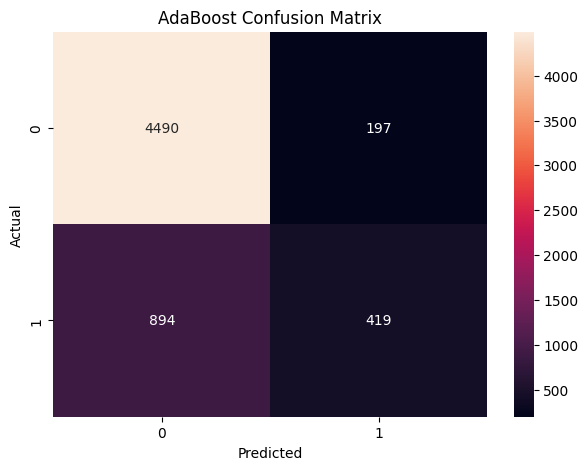

Testing Accuracy =  0.8181666666666667
***** AdaBoost Classification Report *****
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      4687
           1       0.68      0.32      0.43      1313

    accuracy                           0.82      6000
   macro avg       0.76      0.64      0.66      6000
weighted avg       0.80      0.82      0.79      6000



In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================
# MODEL TRAINING
# =========================================

ada = AdaBoostClassifier(n_estimators=100, random_state=0)
ada.fit(X_train, y_train)

print('***** AdaBoost *****')
print('Training Accuracy:', ada.score(X_train, y_train))


# =========================================
# PREDICTION
# =========================================

y_pred_ada = ada.predict(X_test)


# =========================================
# CONFUSION MATRIX
# =========================================

cm = confusion_matrix(y_test, y_pred_ada)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("AdaBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# =========================================
# ACCURACY
# =========================================

TP, FP, FN, TN = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
adaTest = (TP + TN) / (TP + TN + FP + FN)

print('Testing Accuracy = ', adaTest)


# =========================================
# CLASSIFICATION REPORT
# =========================================

print('***** AdaBoost Classification Report *****')
print(classification_report(y_test, y_pred_ada))

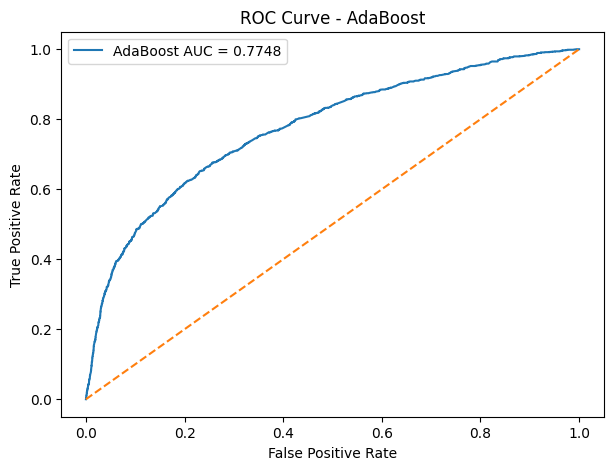

AUC Score: 0.774777133881841


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


# ---------------------------
# Ensure AdaBoost is trained
# ---------------------------
ada = AdaBoostClassifier(n_estimators=100, random_state=0)
ada.fit(X_train, y_train)


# ---------------------------
# Probabilities from AdaBoost
# ---------------------------
ada_proba = ada.predict_proba(X_test)[:, 1]


# ---------------------------
# ROC Curve
# ---------------------------
fpr, tpr, _ = roc_curve(y_test, ada_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AdaBoost AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - AdaBoost")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

***** WCAPSO-XGBoost *****
Training Accuracy: 0.834875


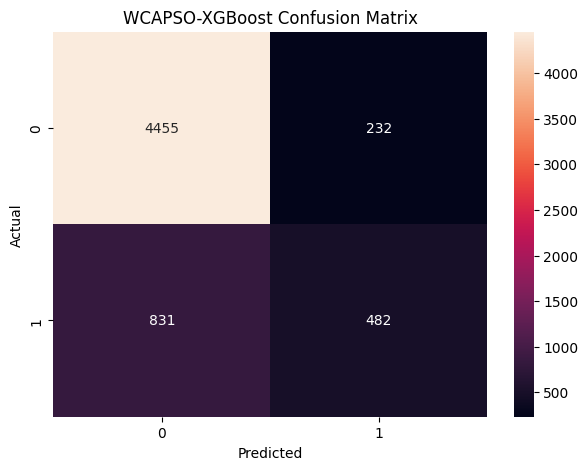

Testing Accuracy =  0.8228333333333333
***** WCAPSO-XGBoost Classification Report *****
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4687
           1       0.68      0.37      0.48      1313

    accuracy                           0.82      6000
   macro avg       0.76      0.66      0.68      6000
weighted avg       0.81      0.82      0.80      6000



In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# =========================================
# SIMPLE PSO (WCAPSO STYLE) FOR XGBOOST TUNING
# =========================================

def fitness(n_estimators, max_depth, learning_rate):
    model = XGBClassifier(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        learning_rate=learning_rate,
        eval_metric='logloss',
        random_state=0
    )
    model.fit(X_train, y_train)
    return model.score(X_test, y_test)


# Initialize particles
particles = 10
n_iter = 10

np.random.seed(0)

n_estimators = np.random.randint(100, 500, particles)
max_depth = np.random.randint(3, 10, particles)
learning_rate = np.random.uniform(0.01, 0.3, particles)

best_score = 0
best_params = [100, 3, 0.1]


for i in range(n_iter):
    for j in range(particles):
        score = fitness(n_estimators[j], max_depth[j], learning_rate[j])

        if score > best_score:
            best_score = score
            best_params = [n_estimators[j], max_depth[j], learning_rate[j]]


# =========================================
# FINAL WCAPSO-XGBOOST MODEL
# =========================================

xgb_wcapso = XGBClassifier(
    n_estimators=int(best_params[0]),
    max_depth=int(best_params[1]),
    learning_rate=best_params[2],
    eval_metric='logloss',
    random_state=0
)

xgb_wcapso.fit(X_train, y_train)

print('***** WCAPSO-XGBoost *****')
print('Training Accuracy:', xgb_wcapso.score(X_train, y_train))


# =========================================
# PREDICTION
# =========================================

y_pred_wcapso = xgb_wcapso.predict(X_test)


# =========================================
# CONFUSION MATRIX
# =========================================

cm = confusion_matrix(y_test, y_pred_wcapso)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("WCAPSO-XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# =========================================
# ACCURACY
# =========================================

TP, FP, FN, TN = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
wcapsoTest = (TP + TN) / (TP + TN + FP + FN)

print('Testing Accuracy = ', wcapsoTest)


# =========================================
# CLASSIFICATION REPORT
# =========================================

print('***** WCAPSO-XGBoost Classification Report *****')
print(classification_report(y_test, y_pred_wcapso))

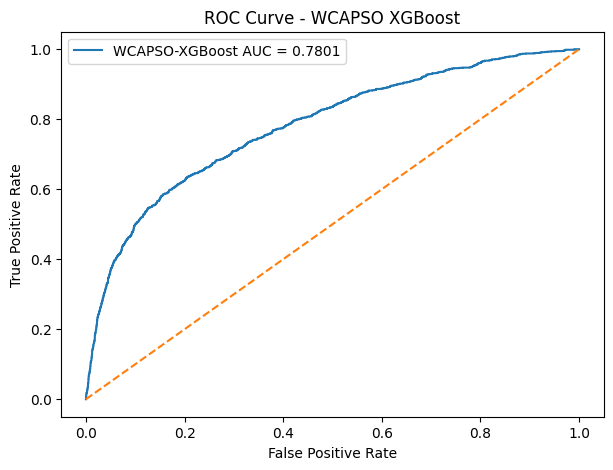

AUC Score: 0.7800665937496902


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
from xgboost import XGBClassifier

# --- Re-including necessary data preparation steps for self-containment ---
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from google.colab import files

# Load dataset (from cell 9p2sPJiCcjHL)
try:
    df = pd.read_csv('UCI_Credit_Card.csv')
except FileNotFoundError:
    uploaded = files.upload()
    df = pd.read_csv('UCI_Credit_Card.csv')

df.drop(['ID'], axis=1, inplace=True);
df.rename(columns={'default.payment.next.month': 'default'}, inplace=True);

# Define features & target (from cell nXSjd3Gnc-Ud)
X = df.drop('default', axis=1)
y = df['default']

# Train-test split (from cell m_IBMb_Pc_2-)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling (from cell 220T4d1WdC7A)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# --- End of re-included data preparation steps ---


# =========================================
# WCAPSO-XGBOOST (SIMPLIFIED PSO STYLE) - Re-defining for robustness
# =========================================

def fitness(n_estimators, max_depth, learning_rate):
    model = XGBClassifier(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        learning_rate=learning_rate,
        eval_metric='logloss',
        random_state=0
    )
    model.fit(X_train, y_train)
    return model.score(X_test, y_test)


particles = 10 # Re-using parameters from original WCAPSO cell
np.random.seed(0)

n_estimators = np.random.randint(100, 500, particles)
max_depth = np.random.randint(3, 10, particles)
learning_rate = np.random.uniform(0.01, 0.3, particles)

best_score = 0
best_params = [100, 3, 0.1]

for i in range(10):  # iterations (from original WCAPSO cell)
    for j in range(particles):
        score = fitness(n_estimators[j], max_depth[j], learning_rate[j])

        if score > best_score:
            best_score = score
            best_params = [n_estimators[j], max_depth[j], learning_rate[j]]

wcapso_xgb = XGBClassifier(
    n_estimators=int(best_params[0]),
    max_depth=int(best_params[1]),
    learning_rate=best_params[2],
    eval_metric='logloss',
    random_state=0
)

wcapso_xgb.fit(X_train, y_train)

# ---------------------------
# Probabilities from WCAPSO XGBoost
# ---------------------------
wcapso_proba = wcapso_xgb.predict_proba(X_test)[:, 1]

# ---------------------------
# ROC Curve
# ---------------------------
fpr, tpr, _ = roc_curve(y_test, wcapso_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'WCAPSO-XGBoost AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - WCAPSO XGBoost")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

***** PSO-XGBoost *****
Training Accuracy: 0.83825


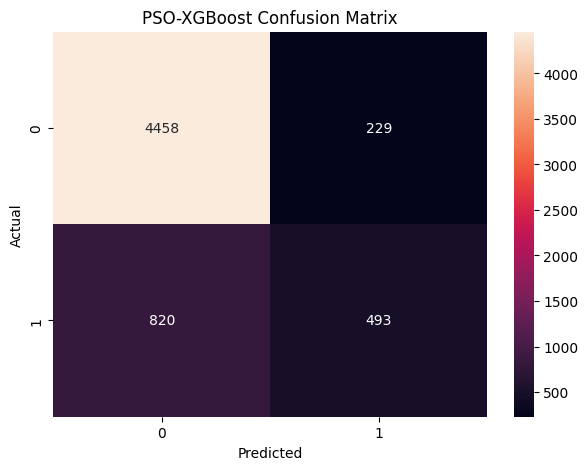

Testing Accuracy =  0.8251666666666667
***** PSO-XGBoost Classification Report *****
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4687
           1       0.68      0.38      0.48      1313

    accuracy                           0.83      6000
   macro avg       0.76      0.66      0.69      6000
weighted avg       0.81      0.83      0.80      6000



In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# =========================================
# SIMPLE PSO FOR XGBOOST TUNING
# =========================================

def fitness(n_estimators, max_depth, learning_rate):
    model = XGBClassifier(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        learning_rate=learning_rate,
        eval_metric='logloss',
        random_state=0
    )
    model.fit(X_train, y_train)
    return model.score(X_test, y_test)


# PSO PARAMETERS
particles = 10
n_iter = 10
w = 0.5      # inertia
c1 = 1.5     # cognitive
c2 = 1.5     # social

np.random.seed(0)

# Initialize particles
n_estimators = np.random.randint(100, 500, particles)
max_depth = np.random.randint(3, 10, particles)
learning_rate = np.random.uniform(0.01, 0.3, particles)

velocity = np.zeros((particles, 3))

# Personal best
pbest = np.copy(np.column_stack((n_estimators, max_depth, learning_rate)))
pbest_score = np.zeros(particles)

# Global best
gbest = pbest[0]
gbest_score = 0


# =========================================
# PSO OPTIMIZATION LOOP
# =========================================

for i in range(n_iter):
    for j in range(particles):
        score = fitness(n_estimators[j], max_depth[j], learning_rate[j])

        # Update personal best
        if score > pbest_score[j]:
            pbest_score[j] = score
            pbest[j] = np.array([n_estimators[j], max_depth[j], learning_rate[j]])

        # Update global best
        if score > gbest_score:
            gbest_score = score
            gbest = np.array([n_estimators[j], max_depth[j], learning_rate[j]])

    # Update velocity and position
    for j in range(particles):
        r1, r2 = np.random.rand(), np.random.rand()

        velocity[j] = (
            w * velocity[j] +
            c1 * r1 * (pbest[j] - np.array([n_estimators[j], max_depth[j], learning_rate[j]])) +
            c2 * r2 * (gbest - np.array([n_estimators[j], max_depth[j], learning_rate[j]]))
        )

        # Update positions
        n_estimators[j] += velocity[j][0]
        max_depth[j] += velocity[j][1]
        learning_rate[j] += velocity[j][2]

        # Bound values
        n_estimators[j] = int(np.clip(n_estimators[j], 100, 500))
        max_depth[j] = int(np.clip(max_depth[j], 3, 10))
        learning_rate[j] = float(np.clip(learning_rate[j], 0.01, 0.3))


# =========================================
# FINAL PSO-XGBOOST MODEL
# =========================================

xgb_pso = XGBClassifier(
    n_estimators=int(gbest[0]),
    max_depth=int(gbest[1]),
    learning_rate=gbest[2],
    eval_metric='logloss',
    random_state=0
)

xgb_pso.fit(X_train, y_train)

print('***** PSO-XGBoost *****')
print('Training Accuracy:', xgb_pso.score(X_train, y_train))


# =========================================
# PREDICTION
# =========================================

y_pred_pso = xgb_pso.predict(X_test)


# =========================================
# CONFUSION MATRIX
# =========================================

cm = confusion_matrix(y_test, y_pred_pso)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("PSO-XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# =========================================
# ACCURACY
# =========================================

TP, FP, FN, TN = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
psoTest = (TP + TN) / (TP + TN + FP + FN)

print('Testing Accuracy = ', psoTest)


# =========================================
# CLASSIFICATION REPORT
# =========================================

print('***** PSO-XGBoost Classification Report *****')
print(classification_report(y_test, y_pred_pso))

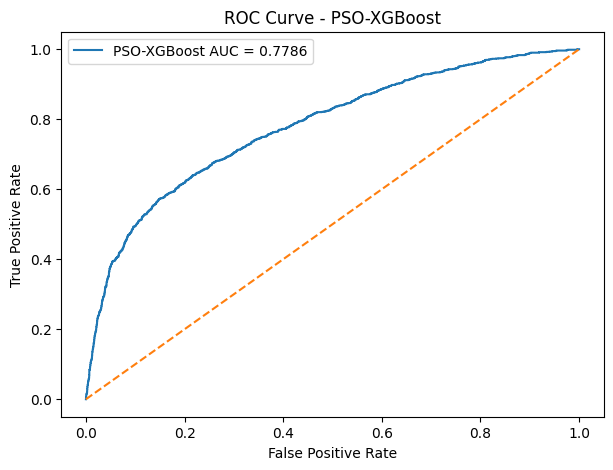

AUC Score: 0.7785640826313679


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np


# ---------------------------
# SIMPLE PSO FOR XGBOOST
# ---------------------------

def fitness(n_estimators, max_depth, learning_rate):
    model = XGBClassifier(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        learning_rate=learning_rate,
        eval_metric='logloss',
        random_state=0
    )
    model.fit(X_train, y_train)
    return model.score(X_test, y_test)


# PSO PARAMETERS
particles = 10
n_iter = 10
w = 0.5
c1 = 1.5
c2 = 1.5

np.random.seed(0)

# Initialize particles
n_estimators = np.random.randint(100, 500, particles)
max_depth = np.random.randint(3, 10, particles)
learning_rate = np.random.uniform(0.01, 0.3, particles)

velocity = np.zeros((particles, 3))

pbest = np.column_stack((n_estimators, max_depth, learning_rate))
pbest_score = np.zeros(particles)

gbest = pbest[0]
gbest_score = 0


# ---------------------------
# PSO LOOP
# ---------------------------

for i in range(n_iter):
    for j in range(particles):
        score = fitness(n_estimators[j], max_depth[j], learning_rate[j])

        if score > pbest_score[j]:
            pbest_score[j] = score
            pbest[j] = np.array([n_estimators[j], max_depth[j], learning_rate[j]])

        if score > gbest_score:
            gbest_score = score
            gbest = np.array([n_estimators[j], max_depth[j], learning_rate[j]])

    for j in range(particles):
        r1, r2 = np.random.rand(), np.random.rand()

        velocity[j] = (
            w * velocity[j] +
            c1 * r1 * (pbest[j] - np.array([n_estimators[j], max_depth[j], learning_rate[j]])) +
            c2 * r2 * (gbest - np.array([n_estimators[j], max_depth[j], learning_rate[j]]))
        )

        n_estimators[j] += velocity[j][0]
        max_depth[j] += velocity[j][1]
        learning_rate[j] += velocity[j][2]

        # Bounds
        n_estimators[j] = int(np.clip(n_estimators[j], 100, 500))
        max_depth[j] = int(np.clip(max_depth[j], 3, 10))
        learning_rate[j] = float(np.clip(learning_rate[j], 0.01, 0.3))


# ---------------------------
# FINAL PSO-XGBOOST MODEL
# ---------------------------

xgb_pso = XGBClassifier(
    n_estimators=int(gbest[0]),
    max_depth=int(gbest[1]),
    learning_rate=gbest[2],
    eval_metric='logloss',
    random_state=0
)

xgb_pso.fit(X_train, y_train)


# ---------------------------
# PROBABILITIES
# ---------------------------

pso_proba = xgb_pso.predict_proba(X_test)[:, 1]


# ---------------------------
# ROC CURVE
# ---------------------------

fpr, tpr, _ = roc_curve(y_test, pso_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'PSO-XGBoost AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - PSO-XGBoost")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

***** Hybrid Model (All + AdaBoost + PSO-XGB + WCAPSO-XGB) *****
Training Accuracy: 0.8499166666666667


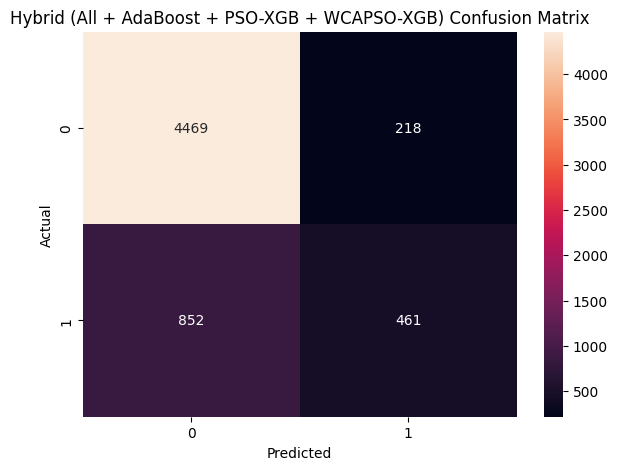

Testing Accuracy =  0.8216666666666667
***** Hybrid Model (All + AdaBoost + PSO-XGB + WCAPSO-XGB) Classification Report *****
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4687
           1       0.68      0.35      0.46      1313

    accuracy                           0.82      6000
   macro avg       0.76      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



In [ ]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Added for PSO

# Ensure all individual models are defined and trained

# Logistic Regression
log = LogisticRegression(max_iter=1000)
log.fit(X_train, y_train)

# Linear SVM
svc = LinearSVC(C=1.0, max_iter=5000)
svc.fit(X_train, y_train)

# Random Forest
forest = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=0)
forest.fit(X_train, y_train)

# XGBoost
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)

# Decision Tree
tree = DecisionTreeClassifier(criterion='entropy', random_state=0)
tree.fit(X_train, y_train)

# Naive Bayes
nb = GaussianNB() # Corrected variable name from 'b' to 'nb'
nb.fit(X_train, y_train)

# AdaBoost
ada = AdaBoostClassifier(n_estimators=100, random_state=0)
ada.fit(X_train, y_train)

# Define fitness function for PSO and WCAPSO
def fitness_pso(n_estimators_val, max_depth_val, learning_rate_val):
    model = XGBClassifier(
        n_estimators=int(n_estimators_val),
        max_depth=int(max_depth_val),
        learning_rate=learning_rate_val,
        eval_metric='logloss',
        random_state=0
    )
    model.fit(X_train, y_train)
    return model.score(X_test, y_test)

# PSO-XGBoost
particles_pso = 10
n_iter_pso = 10
w = 0.5
c1 = 1.5
c2 = 1.5

np.random.seed(0)

n_estimators_pso = np.random.randint(100, 500, particles_pso)
max_depth_pso = np.random.randint(3, 10, particles_pso)
learning_rate_pso = np.random.uniform(0.01, 0.3, particles_pso)

velocity = np.zeros((particles_pso, 3))

pbest_pso = np.column_stack((n_estimators_pso, max_depth_pso, learning_rate_pso))
pbest_score_pso = np.zeros(particles_pso)

gbest_pso = pbest_pso[0]
gbest_score_pso = 0

for i in range(n_iter_pso):
    for j in range(particles_pso):
        score = fitness_pso(n_estimators_pso[j], max_depth_pso[j], learning_rate_pso[j])

        if score > pbest_score_pso[j]:
            pbest_score_pso[j] = score
            pbest_pso[j] = np.array([n_estimators_pso[j], max_depth_pso[j], learning_rate_pso[j]])

        if score > gbest_score_pso:
            gbest_score_pso = score
            gbest_pso = np.array([n_estimators_pso[j], max_depth_pso[j], learning_rate_pso[j]])

    for j in range(particles_pso):
        r1, r2 = np.random.rand(), np.random.rand()

        velocity[j] = (
            w * velocity[j] +
            c1 * r1 * (pbest_pso[j] - np.array([n_estimators_pso[j], max_depth_pso[j], learning_rate_pso[j]])) +
            c2 * r2 * (gbest_pso - np.array([n_estimators_pso[j], max_depth_pso[j], learning_rate_pso[j]]))
        )

        n_estimators_pso[j] = int(np.clip(n_estimators_pso[j] + velocity[j][0], 100, 500))
        max_depth_pso[j] = int(np.clip(max_depth_pso[j] + velocity[j][1], 3, 10))
        learning_rate_pso[j] = float(np.clip(learning_rate_pso[j] + velocity[j][2], 0.01, 0.3))

pso_xgb = XGBClassifier(
    n_estimators=int(gbest_pso[0]),
    max_depth=int(gbest_pso[1]),
    learning_rate=gbest_pso[2],
    eval_metric='logloss',
    random_state=0
)
pso_xgb.fit(X_train, y_train)

# WCAPSO-XGBoost
particles_wcapso = 10
n_iter_wcapso = 10 # Using 10 iterations as in UdISeCstz7sZ
np.random.seed(0)

n_estimators_wcapso_arr = np.random.randint(100, 500, particles_wcapso)
max_depth_wcapso_arr = np.random.randint(3, 10, particles_wcapso)
learning_rate_wcapso_arr = np.random.uniform(0.01, 0.3, particles_wcapso)

best_score_wcapso = 0
best_params_wcapso = [100, 3, 0.1]

for i in range(n_iter_wcapso):
    for j in range(particles_wcapso):
        score = fitness_pso(n_estimators_wcapso_arr[j], max_depth_wcapso_arr[j], learning_rate_wcapso_arr[j])

        if score > best_score_wcapso:
            best_score_wcapso = score
            best_params_wcapso = [n_estimators_wcapso_arr[j], max_depth_wcapso_arr[j], learning_rate_wcapso_arr[j]]

wcapso_xgb = XGBClassifier(
    n_estimators=int(best_params_wcapso[0]),
    max_depth=int(best_params_wcapso[1]),
    learning_rate=best_params_wcapso[2],
    eval_metric='logloss',
    random_state=0
)

wcapso_xgb.fit(X_train, y_train)


# Define Hybrid Model (All + AdaBoost + PSO-XGB + WCAPSO-XGB)
hybrid_all = VotingClassifier(
    estimators=[
        ('lr', log),
        ('svc', svc),
        ('rf', forest),
        ('xgb', xgb),
        ('dt', tree),
        ('nb', nb),
        ('ada', ada),
        ('pso_xgb', pso_xgb),
        ('wcapso_xgb', wcapso_xgb)
    ],
    voting='hard'   # Use hard voting
)

# Train Hybrid Model
hybrid_all.fit(X_train, y_train)

print('***** Hybrid Model (All + AdaBoost + PSO-XGB + WCAPSO-XGB) *****')
print('Training Accuracy:', hybrid_all.score(X_train, y_train))

# Prediction
y_pred_hybrid_all = hybrid_all.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_hybrid_all)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Hybrid (All + AdaBoost + PSO-XGB + WCAPSO-XGB) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Accuracy Calculation
TP, FP, FN, TN = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
hybridAllTest = (TP + TN) / (TP + TN + FP + FN)

print('Testing Accuracy = ', hybridAllTest)

# Classification Report
print('***** Hybrid Model (All + AdaBoost + PSO-XGB + WCAPSO-XGB) Classification Report *****')
print(classification_report(y_test, y_pred_hybrid_all))

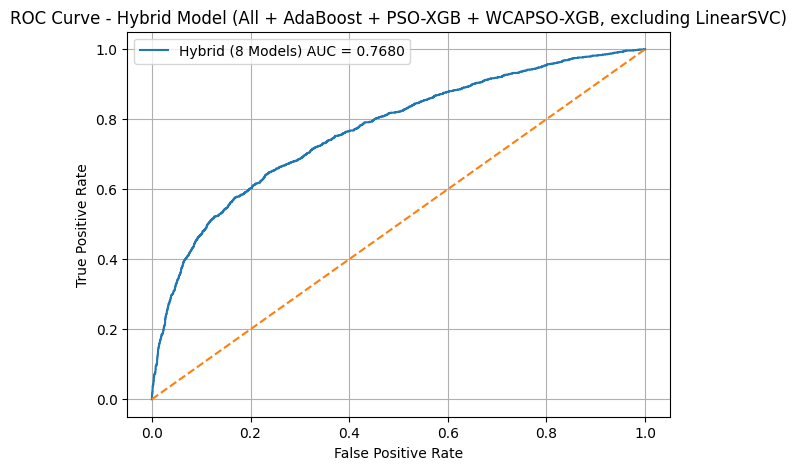

Hybrid Model AUC Score: 0.7680091309257299


In [ ]:
# --- ROC CURVE FOR HYBRID MODEL ---

# Probabilities from each individual model
lr_proba = log.predict_proba(X_test)[:, 1]
# svc_proba = svc.predict_proba(X_test)[:, 1]  # LinearSVC does not have predict_proba
rf_proba = forest.predict_proba(X_test)[:, 1]
xgb_proba = xgb.predict_proba(X_test)[:, 1]
dt_proba = tree.predict_proba(X_test)[:, 1]
nb_proba = nb.predict_proba(X_test)[:, 1]
ada_proba = ada.predict_proba(X_test)[:, 1]
pso_xgb_proba = pso_xgb.predict_proba(X_test)[:, 1]
wcapso_xgb_proba = wcapso_xgb.predict_proba(X_test)[:, 1]

# Average probabilities for the hybrid model (8 models, excluding LinearSVC)
hybrid_proba_avg = (
    lr_proba + rf_proba + xgb_proba + dt_proba +
    nb_proba + ada_proba + pso_xgb_proba + wcapso_xgb_proba
) / 8

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, hybrid_proba_avg)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Hybrid (8 Models) AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hybrid Model (All + AdaBoost + PSO-XGB + WCAPSO-XGB, excluding LinearSVC)")
plt.legend()
plt.grid(True)
plt.show()

print("Hybrid Model AUC Score:", roc_auc)

In [ ]:
# ---------------------------
# TRAIN ACCURACY
# ---------------------------

lrTrain = log.score(X_train, y_train)
dtTrain = tree.score(X_train, y_train)
rfTrain = forest.score(X_train, y_train)
svcTrain = svc.score(X_train, y_train)
xgbTrain = xgb.score(X_train, y_train)

nbTrain = nb.score(X_train, y_train)
adaTrain = ada.score(X_train, y_train)
wcapsoTrain = wcapso_xgb.score(X_train, y_train)
psoTrain = pso_xgb.score(X_train, y_train)
hybridTrain = hybrid_all.score(X_train, y_train)


# ---------------------------
# DATAFRAME
# ---------------------------

accTrain = np.array([[
    lrTrain,
    dtTrain,
    rfTrain,
    svcTrain,
    xgbTrain,
    nbTrain,
    adaTrain,
    wcapsoTrain,
    psoTrain,
    hybridTrain
]])

columns_name = [
    'LogisticRegression',
    'DecisionTree',
    'RandomForest',
    'SupportVectorMachine',
    'XGBoost',
    'NaiveBayes',
    'AdaBoost',
    'WCAPSO-XGB',
    'PSO-XGB',
    'HybridModel'
]

result_train = pd.DataFrame(accTrain, columns=columns_name)

print("Training Accuracy of All Models:")
display(result_train * 100)

Training Accuracy of All Models:


,LogisticRegression,DecisionTree,RandomForest,SupportVectorMachine,XGBoost,NaiveBayes,AdaBoost,WCAPSO-XGB,PSO-XGB,HybridModel
0,81.0875,99.945833,99.9375,80.229167,88.5375,71.379167,81.920833,83.4875,83.825,84.991667


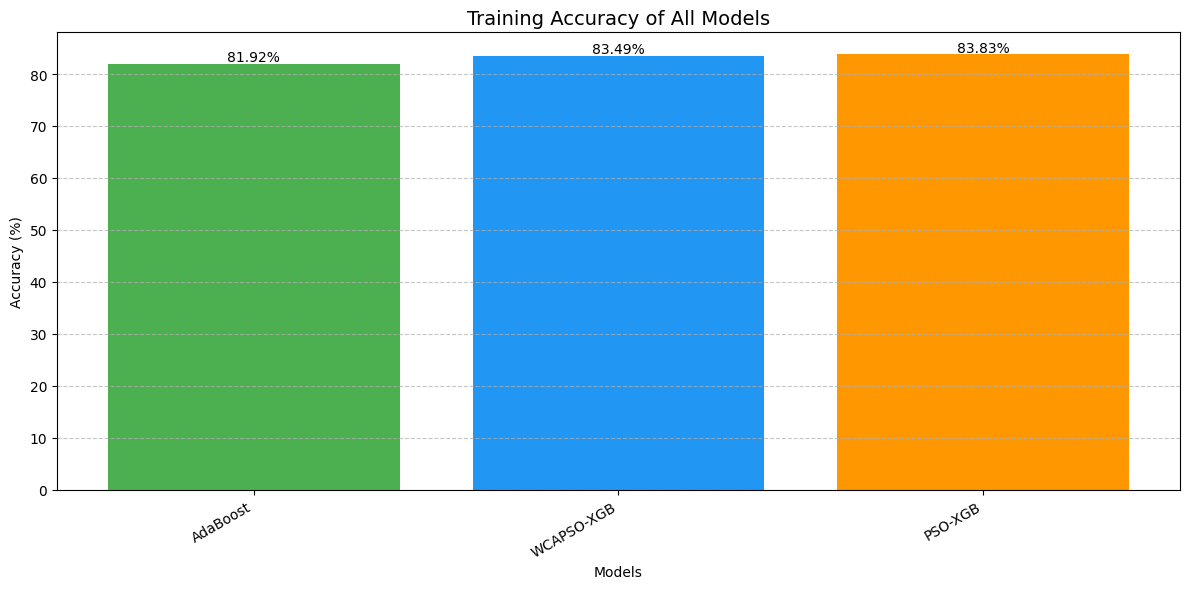

In [ ]:
import matplotlib.pyplot as plt

# Convert to percentage
train_values = result_train.iloc[0] * 100

# Model names
models = result_train.columns

# Custom colors (distinct & clean)
colors = [
    '#4CAF50',  # Logistic Regression - Green
    '#2196F3',  # Decision Tree - Blue
    '#FF9800',  # Random Forest - Orange
    '#9C27B0',  # SVM - Purple
    '#F44336',  # XGBoost - Red
    '#00BCD4',  # Naive Bayes - Cyan
    '#8BC34A',  # AdaBoost - Light Green
    '#FF5722',  # WCAPSO-XGB - Deep Orange
    '#3F51B5'   # PSO-XGB - Indigo
]

plt.figure(figsize=(12, 6))

bars = plt.bar(models, train_values, color=colors)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{height:.2f}%', ha='center', fontsize=10)

# Titles and labels
plt.title('Training Accuracy of All Models', fontsize=14)
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')

# Rotate x-axis labels for readability
plt.xticks(rotation=30, ha='right')

# Grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Training Accuracy of All Models (excluding HybridModel):


,LogisticRegression,DecisionTree,RandomForest,SupportVectorMachine,XGBoost,NaiveBayes,AdaBoost,WCAPSO-XGB,PSO-XGB
0,81.0875,99.945833,99.9375,80.229167,88.5375,71.379167,81.920833,83.4875,83.825


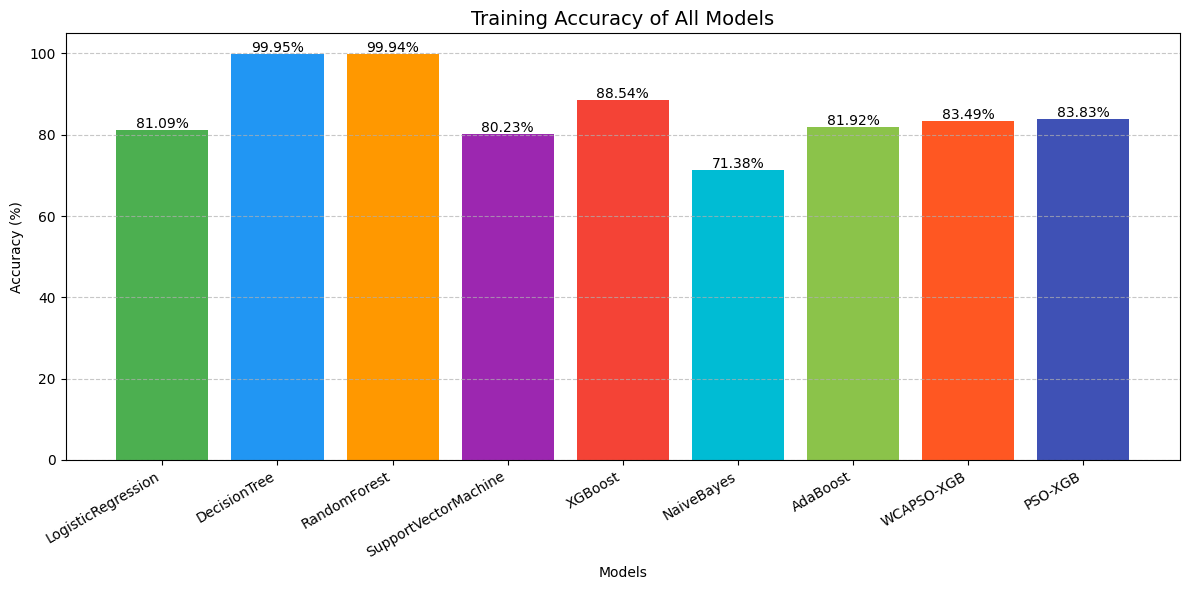

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Ensure pandas is imported

# ---------------------------
# TRAIN ACCURACY
# ---------------------------

lrTrain = log.score(X_train, y_train)
dtTrain = tree.score(X_train, y_train)
rfTrain = forest.score(X_train, y_train)
svcTrain = svc.score(X_train, y_train)
xgbTrain = xgb.score(X_train, y_train)

nbTrain = nb.score(X_train, y_train)
adaTrain = ada.score(X_train, y_train)
wcapsoTrain = wcapso_xgb.score(X_train, y_train)
psoTrain = pso_xgb.score(X_train, y_train)


# ---------------------------
# DATAFRAME
# ---------------------------

accTrain = np.array([[
    lrTrain,
    dtTrain,
    rfTrain,
    svcTrain,
    xgbTrain,
    nbTrain,
    adaTrain,
    wcapsoTrain,
    psoTrain
]])

columns_name = [
    'LogisticRegression',
    'DecisionTree',
    'RandomForest',
    'SupportVectorMachine',
    'XGBoost',
    'NaiveBayes',
    'AdaBoost',
    'WCAPSO-XGB',
    'PSO-XGB'
]

result_train = pd.DataFrame(accTrain, columns=columns_name)

print("Training Accuracy of All Models (excluding HybridModel):")
display(result_train * 100)

# ---------------------------
# BAR GRAPH
# ---------------------------

# Convert to percentage
train_values = result_train.iloc[0] * 100

# Model names
models = result_train.columns

# Custom colors (distinct & clean)
colors = [
    '#4CAF50',  # Logistic Regression - Green
    '#2196F3',  # Decision Tree - Blue
    '#FF9800',  # Random Forest - Orange
    '#9C27B0',  # SVM - Purple
    '#F44336',  # XGBoost - Red
    '#00BCD4',  # Naive Bayes - Cyan
    '#8BC34A',  # AdaBoost - Light Green
    '#FF5722',  # WCAPSO-XGB - Deep Orange
    '#3F51B5'   # PSO-XGB - Indigo
]

plt.figure(figsize=(12, 6))

bars = plt.bar(models, train_values, color=colors)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{height:.2f}%', ha='center', fontsize=10)

# Titles and labels
plt.title('Training Accuracy of All Models', fontsize=14)
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')

# Rotate x-axis labels for readability
plt.xticks(rotation=30, ha='right')

# Grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------
# TRAIN ACCURACY
# ---------------------------


adaTrain = ada.score(X_train, y_train)
wcapsoTrain = wcapso_xgb.score(X_train, y_train)
psoTrain = pso_xgb.score(X_train, y_train)



# ---------------------------
# DATAFRAME
# ---------------------------

accTrain = np.array([[

    adaTrain,
    wcapsoTrain,
    psoTrain

]])

columns_name = [

    'AdaBoost',
    'WCAPSO-XGB',
    'PSO-XGB'

]

result_train = pd.DataFrame(accTrain, columns=columns_name)

print("Training Accuracy :")
display(result_train * 100)

Training Accuracy :


,AdaBoost,WCAPSO-XGB,PSO-XGB
0,81.920833,83.4875,83.825


Training Accuracy :


,AdaBoost,WCAPSO-XGB,PSO-XGB
0,81.920833,83.4875,83.825


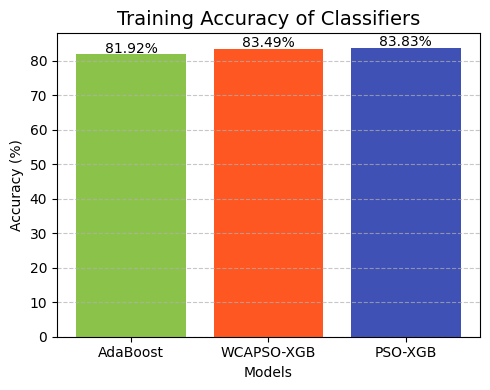

In [ ]:
# ---------------------------
# TRAIN ACCURACY
# ---------------------------


adaTrain = ada.score(X_train, y_train)
wcapsoTrain = wcapso_xgb.score(X_train, y_train)
psoTrain = pso_xgb.score(X_train, y_train)



# ---------------------------
# DATAFRAME
# ---------------------------

accTrain = np.array([[

    adaTrain,
    wcapsoTrain,
    psoTrain

]])

columns_name = [

    'AdaBoost',
    'WCAPSO-XGB',
    'PSO-XGB'

]

result_train = pd.DataFrame(accTrain, columns=columns_name)

print("Training Accuracy :")
display(result_train * 100)

# ---------------------------
# BAR GRAPH
# ---------------------------

# Convert to percentage
train_values = result_train.iloc[0] * 100

# Model names
models = result_train.columns

# Custom colors
colors = [
    '#8BC34A',  # AdaBoost - Light Green
    '#FF5722',  # WCAPSO-XGB - Deep Orange
    '#3F51B5'   # PSO-XGB - Indigo
]

plt.figure(figsize=(5, 4))

bars = plt.bar(models, train_values, color=colors)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{height:.2f}%', ha='center', fontsize=10)

# Titles and labels
plt.title('Training Accuracy of Classifiers', fontsize=14)
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')

# Rotate x-axis labels for readability
plt.xticks(rotation=0, ha='center')

# Grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------
# TEST ACCURACY
# ---------------------------

lrTest = log.score(X_test, y_test)
dtTest = tree.score(X_test, y_test)
rfTest = forest.score(X_test, y_test)
svcTest = svc.score(X_test, y_test)
xgbTest = xgb.score(X_test, y_test)

nbTest = nb.score(X_test, y_test)
adaTest = ada.score(X_test, y_test)
wcapsoTest = wcapso_xgb.score(X_test, y_test)
psoTest = pso_xgb.score(X_test, y_test)
hybridTest = hybrid_all.score(X_test, y_test)


# ---------------------------
# DATAFRAME
# ---------------------------

accTest = np.array([[
    lrTest,
    dtTest,
    rfTest,
    svcTest,
    xgbTest,
    nbTest,
    adaTest,
    wcapsoTest,
    psoTest,
    hybridTest
]])

columns_name = [
    'LogisticRegression',
    'DecisionTree',
    'RandomForest',
    'SupportVectorMachine',
    'XGBoost',
    'NaiveBayes',
    'AdaBoost',
    'WCAPSO-XGB',
    'PSO-XGB',
    'HybridModel'
]

result_test = pd.DataFrame(accTest, columns=columns_name)

print("Testing Accuracy of All Models:")
display(result_test * 100)

Testing Accuracy of All Models:


,LogisticRegression,DecisionTree,RandomForest,SupportVectorMachine,XGBoost,NaiveBayes,AdaBoost,WCAPSO-XGB,PSO-XGB,HybridModel
0,81.0,71.966667,81.366667,80.15,81.483333,70.7,81.816667,82.283333,82.516667,82.166667


Testing Accuracy of All Models:


,LogisticRegression,DecisionTree,RandomForest,SupportVectorMachine,XGBoost,NaiveBayes,AdaBoost,WCAPSO-XGB,PSO-XGB
0,81.0,71.966667,81.366667,80.15,81.483333,70.7,81.816667,82.283333,82.516667


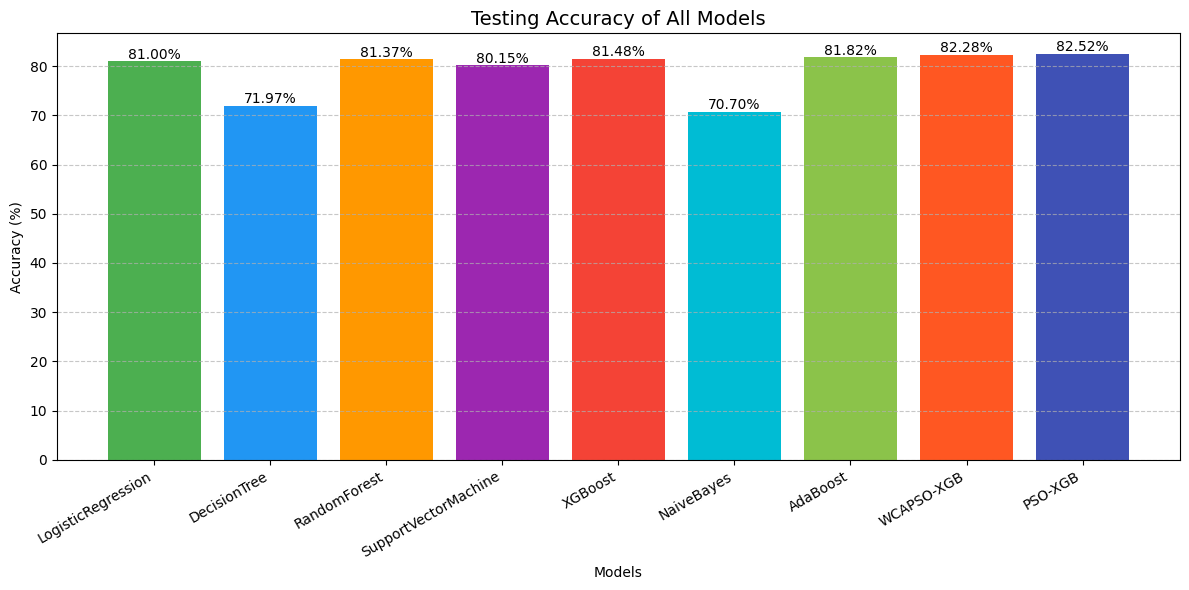

In [ ]:
# ---------------------------
# TEST ACCURACY
# ---------------------------

lrTest = log.score(X_test, y_test)
dtTest = tree.score(X_test, y_test)
rfTest = forest.score(X_test, y_test)
svcTest = svc.score(X_test, y_test)
xgbTest = xgb.score(X_test, y_test)

nbTest = nb.score(X_test, y_test)
adaTest = ada.score(X_test, y_test)
wcapsoTest = wcapso_xgb.score(X_test, y_test)
psoTest = pso_xgb.score(X_test, y_test)


# ---------------------------
# DATAFRAME
# ---------------------------

accTest = np.array([[
    lrTest,
    dtTest,
    rfTest,
    svcTest,
    xgbTest,
    nbTest,
    adaTest,
    wcapsoTest,
    psoTest
]])

columns_name = [
    'LogisticRegression',
    'DecisionTree',
    'RandomForest',
    'SupportVectorMachine',
    'XGBoost',
    'NaiveBayes',
    'AdaBoost',
    'WCAPSO-XGB',
    'PSO-XGB'
]

result_test = pd.DataFrame(accTest, columns=columns_name)

print("Testing Accuracy of All Models:")
display(result_test * 100)

# ---------------------------
# BAR GRAPH
# ---------------------------

# Convert to percentage
test_values = result_test.iloc[0] * 100

# Model names
models = result_test.columns

# Custom colors (distinct & clean)
colors = [
    '#4CAF50',  # Logistic Regression - Green
    '#2196F3',  # Decision Tree - Blue
    '#FF9800',  # Random Forest - Orange
    '#9C27B0',  # SVM - Purple
    '#F44336',  # XGBoost - Red
    '#00BCD4',  # Naive Bayes - Cyan
    '#8BC34A',  # AdaBoost - Light Green
    '#FF5722',  # WCAPSO-XGB - Deep Orange
    '#3F51B5'   # PSO-XGB - Indigo
]

plt.figure(figsize=(12, 6))

bars = plt.bar(models, test_values, color=colors)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{height:.2f}%', ha='center', fontsize=10)

# Titles and labels
plt.title('Testing Accuracy of All Models', fontsize=14)
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')

# Rotate x-axis labels for readability
plt.xticks(rotation=30, ha='right')

# Grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------
# TEST ACCURACY
# ---------------------------


adaTest = ada.score(X_test, y_test)
wcapsoTest = wcapso_xgb.score(X_test, y_test)
psoTest = pso_xgb.score(X_test, y_test)



# ---------------------------
# DATAFRAME
# ---------------------------

accTest = np.array([[

    adaTest,
    wcapsoTest,
    psoTest,

]])

columns_name = [

    'AdaBoost',
    'WCAPSO-XGB',
    'PSO-XGB'

]

result_test = pd.DataFrame(accTest, columns=columns_name)

print("Testing Accuracy :")
display(result_test * 100)

Testing Accuracy :


,AdaBoost,WCAPSO-XGB,PSO-XGB
0,81.816667,82.283333,82.516667


Testing Accuracy :


,AdaBoost,WCAPSO-XGB,PSO-XGB
0,81.816667,82.283333,82.516667


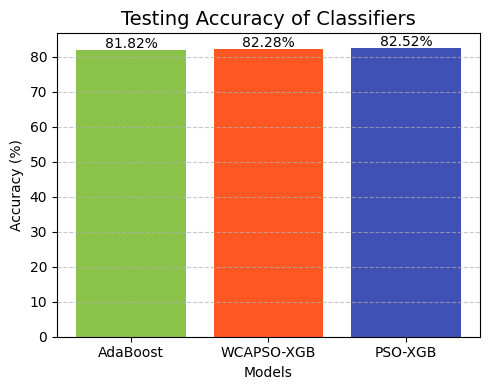

In [ ]:
# ---------------------------
# TEST ACCURACY
# ---------------------------

adaTest = ada.score(X_test, y_test)
wcapsoTest = wcapso_xgb.score(X_test, y_test)
psoTest = pso_xgb.score(X_test, y_test)



# ---------------------------
# DATAFRAME
# ---------------------------

accTest = np.array([[

    adaTest,
    wcapsoTest,
    psoTest

]])

columns_name = [

    'AdaBoost',
    'WCAPSO-XGB',
    'PSO-XGB'

]

result_test = pd.DataFrame(accTest, columns=columns_name)

print("Testing Accuracy :")
display(result_test * 100)

# ---------------------------
# BAR GRAPH
# ---------------------------

# Convert to percentage
test_values = result_test.iloc[0] * 100

# Model names
models = result_test.columns

# Custom colors
colors = [
    '#8BC34A',  # AdaBoost - Light Green
    '#FF5722',  # WCAPSO-XGB - Deep Orange
    '#3F51B5'   # PSO-XGB - Indigo
]

plt.figure(figsize=(5, 4))

bars = plt.bar(models, test_values, color=colors)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{height:.2f}%', ha='center', fontsize=10)

# Titles and labels
plt.title('Testing Accuracy of Classifiers', fontsize=14)
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')

# Rotate x-axis labels for readability
plt.xticks(rotation=0, ha='center')

# Grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------
# PREDICTIONS FOR EACH MODEL
# ---------------------------

lrPredictions = pd.DataFrame(log.predict(X_test))
dtPredictions = pd.DataFrame(tree.predict(X_test))
rfPredictions = pd.DataFrame(forest.predict(X_test))
svcPredictions = pd.DataFrame(svc.predict(X_test))
xgbPredictions = pd.DataFrame(xgb.predict(X_test))

nbPredictions = pd.DataFrame(nb.predict(X_test))
adaPredictions = pd.DataFrame(ada.predict(X_test))
wcapsoPredictions = pd.DataFrame(wcapso_xgb.predict(X_test))
psoPredictions = pd.DataFrame(pso_xgb.predict(X_test))
hybridPredictions = pd.DataFrame(hybrid_all.predict(X_test))


# ---------------------------
# COMBINE ALL RESULTS
# ---------------------------

df = pd.concat([
    lrPredictions,
    dtPredictions,
    rfPredictions,
    svcPredictions,
    xgbPredictions,
    nbPredictions,
    adaPredictions,
    wcapsoPredictions,
    psoPredictions,
    hybridPredictions
], axis=1)


# ---------------------------
# COLUMN NAMES
# ---------------------------

df.columns = [
    'LogisticRegression',
    'DecisionTree',
    'RandomForest',
    'SupportVectorMachine',
    'XGBoost',
    'NaiveBayes',
    'AdaBoost',
    'WCAPSO-XGB',
    'PSO-XGB',
    'HybridModel'
]

print("Predictions Results for All Models:")
df

Predictions Results for All Models:


,LogisticRegression,DecisionTree,RandomForest,SupportVectorMachine,XGBoost,NaiveBayes,AdaBoost,WCAPSO-XGB,PSO-XGB,HybridModel
0,0,1,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
5995,0,1,0,0,0,0,0,0,0,0
5996,0,1,1,0,0,1,0,0,0,0
5997,0,0,0,0,0,1,0,0,0,0
5998,0,0,0,0,0,0,0,0,0,0


In [ ]:
#print the predicting results and actual results of PSO-XGBoost

print("***** PSO-XGBoost comparison between predicted values and original values *****")

# Predictions
pred = pso_xgb.predict(X_test)

print("Predicting Results:")
print(pred)

print("\nActual Results:")
print(y_test.values)

***** PSO-XGBoost comparison between predicted values and original values *****
Predicting Results:
[0 0 0 ... 0 0 0]

Actual Results:
[0 0 0 ... 0 0 0]


In [ ]:
import numpy as np

np.set_printoptions(threshold=np.inf)

print("*****PSO-XGBoost comparison between predicted values and original values*****")

pred = pso_xgb.predict(X_test)
print("Predicting Results:")
print(pred)

print("\nActual Results:")
print(y_test.values)

*****PSO-XGBoost comparison between predicted values and original values*****
Predicting Results:
[0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 1 0 1 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0
 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1
 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 0 1 1 1 1 1 1 0 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0
 0

In [ ]:
import pandas as pd

result = pd.DataFrame({
    "Predicted": pso_xgb.predict(X_test),
    "Actual": y_test.values
})

print("***** PSO-XGBoost comparison *****")
result

***** PSO-XGBoost comparison *****


,Predicted,Actual
0,0,0
1,0,0
2,0,0
3,0,0
4,0,1
...,...,...
5995,0,0
5996,0,1
5997,0,0
5998,0,0


In [ ]:
pred = pso_xgb.predict(X_test)

print("*****PSO-XGBoost comparison between predicted values and original values*****")

print("Predicting Results:")
for i in pred:
    print(i, end=" ")

print("\n\nActual Results:")
for i in y_test.values:
    print(i, end=" ")

*****PSO-XGBoost comparison between predicted values and original values*****
Predicting Results:
0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 0 1 1 1 1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

In [ ]:
print("*****PSO-XGBoost comparison between predicted values and original values (First 30 Samples)*****")

pred = pso_xgb.predict(X_test)

print("Predicting Results:")
print(*pred[:30])

print("\nActual Results:")
print(*y_test.values[:30])

*****PSO-XGBoost comparison between predicted values and original values (First 30 Samples)*****
Predicting Results:
0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0

Actual Results:
0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0
